# **FEATURE ENGINEERING NOTEBOOK**

## **0. Library import**

This section imports the libraries required for feature engineering, including pandas for data processing, matplotlib and seaborn for visualization, sklearn for data segmentation, and the `DiabetesFeatureEngineering` class from the custom module to perform the entire feature engineering process systematically.

In [1]:
import os
import sys

# Add the root path into the python path
root_path = os.path.abspath(os.path.join(".."))
if not root_path in sys.path:
    sys.path.insert(0, root_path)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import DiabetesFeatureEngineering
from src.config import BRFSS_CLEANED_FILE_PATH, LOG_DIR

## **1. Load dataset**

This section loads the processed BRFSS dataset from the data pipeline with size (787,602, 21), which means there are 787,602 records with 21 features. This is the original dataset that has not been feature engineered, still has issues such as duplicate records, outliers, and no new features created from domain knowledge.

In [3]:
# Load preprocessed BRFSS dataset for feature engineering
df = pd.read_csv(filepath_or_buffer=BRFSS_CLEANED_FILE_PATH)
df.shape

(787602, 21)

## **2. Feature engineering**

This is the heart of the notebook, performing the entire feature engineering process through the `DiabetesFeatureEngineering` class. From the log output, we see that this process involves several important steps.

**=== FEATURE ENGINEERING SUMMARY ===**

Original dataset: (787,602, 21)
Final dataset: (702,516, 15)

- Removed 85,086 duplicates (10.80%)
- Handled 214,340 outliers across 3 features
- Created four new composite features
- Selected 14 most predictive features
- Ready for model training

In [4]:
diabetes_feature_engineering = DiabetesFeatureEngineering(log_file=f"{LOG_DIR}/3_feature_engineering.log")

2025-09-16 21:15:05,191 - [src.features] - INFO - DiabetesFeatureEngineering initialized successfully


### **2.1 Remove null values**

From `df.info()` and the log output, we see that the original dataset has no missing values; all 21 columns have 787,602 non-null entries. This shows that the previous data pipeline handled missing data well. This step is a sanity check to ensure that no null values are created during processing.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787602 entries, 0 to 787601
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes              787602 non-null  float64
 1   HighBP                787602 non-null  float64
 2   HighChol              787602 non-null  float64
 3   CholCheck             787602 non-null  float64
 4   BMI                   787602 non-null  float64
 5   Smoker                787602 non-null  float64
 6   Stroke                787602 non-null  float64
 7   HeartDiseaseorAttack  787602 non-null  float64
 8   PhysActivity          787602 non-null  float64
 9   HvyAlcoholConsump     787602 non-null  float64
 10  AnyHealthcare         787602 non-null  float64
 11  NoDocbcCost           787602 non-null  float64
 12  GenHlth               787602 non-null  float64
 13  MentHlth              787602 non-null  float64
 14  PhysHlth              787602 non-null  float64
 15  

In [6]:
# Step 1: Check and remove null values (data quality assurance)
clean_df = diabetes_feature_engineering.remove_null_values(df=df)

2025-09-16 21:15:05,237 - [src.features] - INFO - Starting null values removal process...
2025-09-16 21:15:05,257 - [src.features] - INFO - No null values found in the dataset
2025-09-16 21:15:05,322 - [src.features] - INFO - Null values removal completed. Removed 0 rows (0.00%)
2025-09-16 21:15:05,323 - [src.features] - INFO - Dataset shape: 787602 -> 787602 rows


In [7]:
clean_df.isnull().sum()

Diabetes                0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Year                    0
dtype: int64

### **2.2 Remove duplicate values**

This process detected and removed 85,086 duplicate rows (10.80% of the dataset), reducing the dataset size from 787,602 to 702,516 records. Removing duplicates is important because:

- Avoid overfitting due to the model learning the same patterns many times
- Improve the representativeness of the dataset
- Reduce computational costs in training

In [8]:
# Before removing duplicate rows
clean_df.shape

(787602, 21)

In [9]:
# Step 2: Remove duplicate records to prevent overfitting
no_dup_df = diabetes_feature_engineering.remove_duplicates(df=clean_df)

2025-09-16 21:15:05,367 - [src.features] - INFO - Starting duplicate removal process...
2025-09-16 21:15:05,600 - [src.features] - INFO - Found 85086 duplicate rows
2025-09-16 21:15:05,646 - [src.features] - INFO -   - Label 2.0: 1588 duplicate rows
2025-09-16 21:15:05,907 - [src.features] - INFO -   - Label 0.0: 83425 duplicate rows
2025-09-16 21:15:05,918 - [src.features] - INFO -   - Label 1.0: 73 duplicate rows
2025-09-16 21:15:06,208 - [src.features] - INFO - Duplicate removal completed. Removed 85086 rows (10.80%)
2025-09-16 21:15:06,209 - [src.features] - INFO - Dataset shape: 787602 -> 702516 rows


In [10]:
# After removing duplicate rows
no_dup_df.shape

(702516, 21)

### **2.3 Handle outliers**

The outliers section focuses on 3 continuous features: BMI, MentHlth, and PhysHlth. From the log, we see:

**BMI**: There are 18,685 outliers (mostly in the upper bound), likely to be unrealistically high BMI values (>40–50) or due to data entry errors. These values are capped to the reasonable threshold.

**MentHlth**: There are 90,551 outliers, this is the number of days in the month with mental health problems. Upper outliers may be those who reported >30 days (unreasonable since the month only has 30–31 days).

**PhysHlth**: There are 105,104 outliers similar to MentHlth, which is the number of days in the month with physical health problems.

A total of 214,340 outliers were processed, which improved data quality and prevented the model from being affected by extreme values.

In [11]:
# Step 3: Handle outliers using IQR method for BMI, MentHlth, PhysHlth
outliers_df = diabetes_feature_engineering.handle_outliers(df=no_dup_df)

2025-09-16 21:15:06,224 - [src.features] - INFO - Starting outlier handling process...
2025-09-16 21:15:06,226 - [src.features] - INFO - Columns to process: ['BMI', 'MentHlth', 'PhysHlth']
2025-09-16 21:15:06,252 - [src.features] - INFO - Processing outliers for column: BMI
2025-09-16 21:15:06,309 - [src.features] - INFO -   - Diabetes group 2.0: 2770 outliers (Lower: 11, Upper: 2759)
2025-09-16 21:15:06,473 - [src.features] - INFO -   - Diabetes group 0.0: 21098 outliers (Lower: 110, Upper: 20988)
2025-09-16 21:15:06,497 - [src.features] - INFO -   - Diabetes group 1.0: 624 outliers (Lower: 7, Upper: 617)
2025-09-16 21:15:06,507 - [src.features] - INFO - Processing outliers for column: MentHlth
2025-09-16 21:15:06,563 - [src.features] - INFO -   - Diabetes group 2.0: 17445 outliers (Lower: 0, Upper: 17445)
2025-09-16 21:15:06,714 - [src.features] - INFO -   - Diabetes group 0.0: 92100 outliers (Lower: 0, Upper: 92100)
2025-09-16 21:15:06,741 - [src.features] - INFO -   - Diabetes grou

The boxplot comparison shows a clear difference before and after outlier processing, with extreme values controlled within a reasonable range.

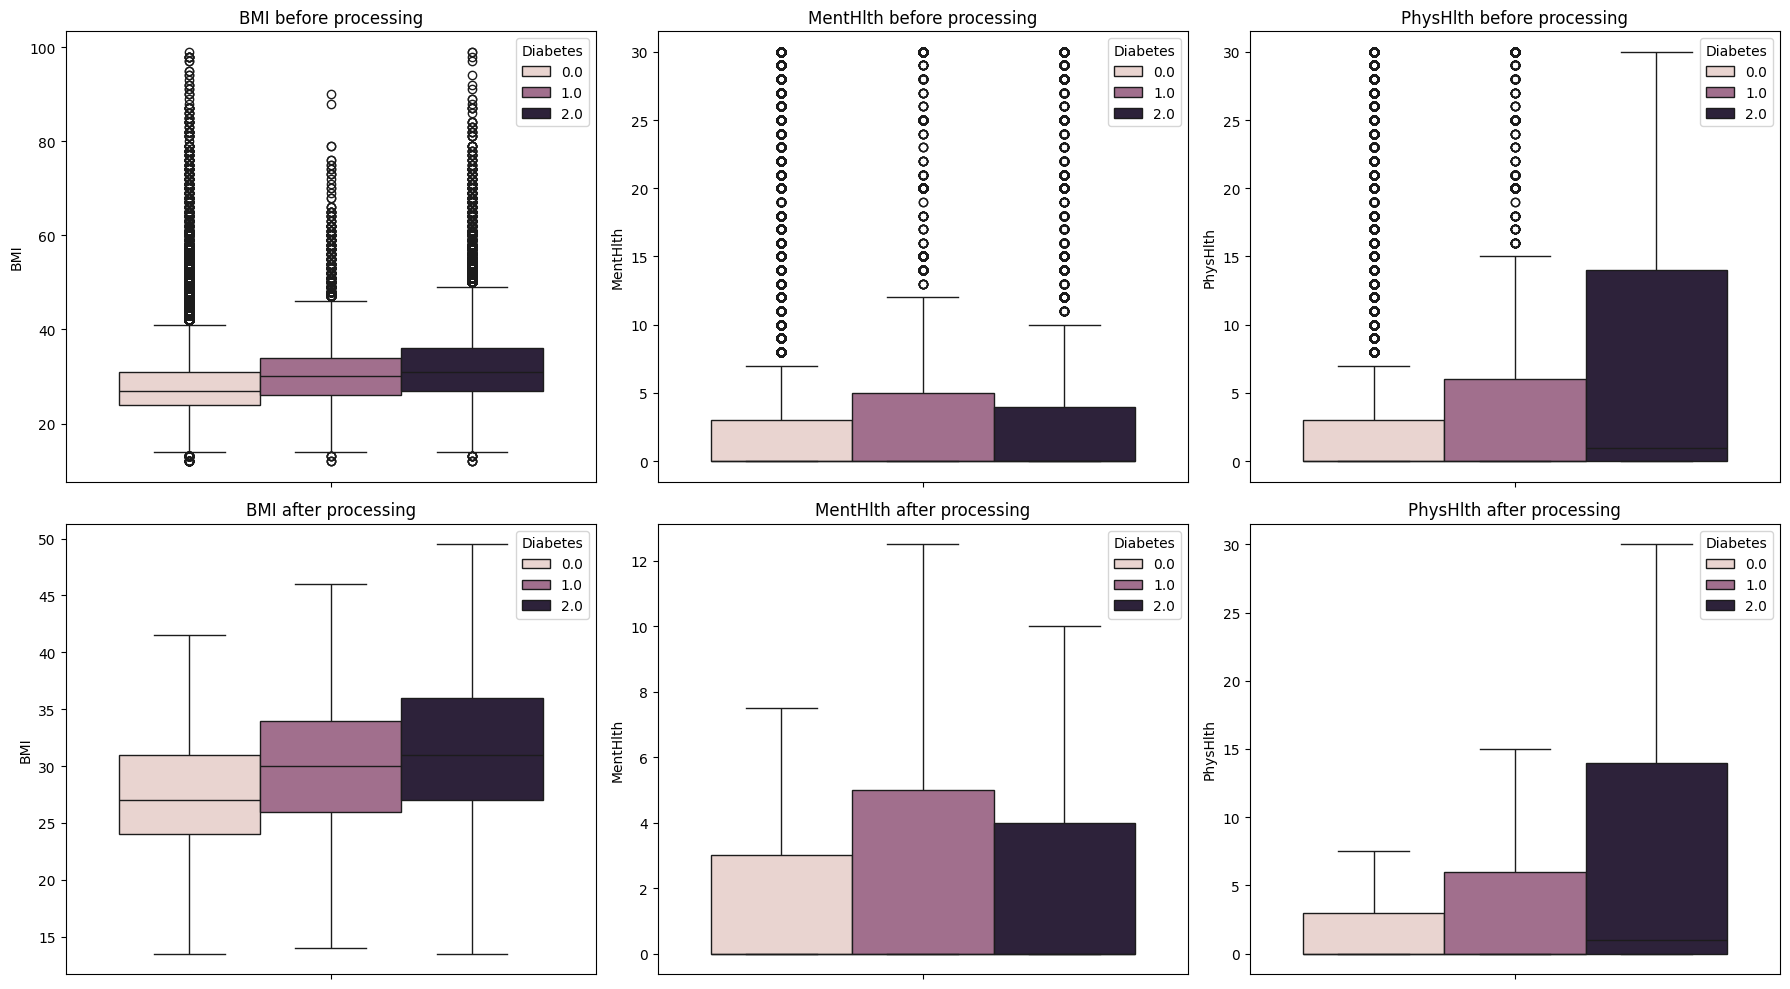

In [12]:
# Plot comparison chart before and after processing
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Before processing
sns.boxplot(data=no_dup_df, y='BMI', hue='Diabetes', ax=axes[0,0])
axes[0,0].set_title('BMI before processing')
sns.boxplot(data=no_dup_df, y='MentHlth', hue='Diabetes', ax=axes[0,1])
axes[0,1].set_title('MentHlth before processing')
sns.boxplot(data=no_dup_df, y='PhysHlth', hue='Diabetes', ax=axes[0,2])
axes[0,2].set_title('PhysHlth before processing')

# After processing
sns.boxplot(data=outliers_df, y='BMI', hue='Diabetes', ax=axes[1,0])
axes[1,0].set_title('BMI after processing')
sns.boxplot(data=outliers_df, y='MentHlth', hue='Diabetes', ax=axes[1,1])
axes[1,1].set_title('MentHlth after processing')
sns.boxplot(data=outliers_df, y='PhysHlth', hue='Diabetes', ax=axes[1,2])
axes[1,2].set_title('PhysHlth after processing')

plt.tight_layout()
plt.show()

### **2.4 Exploratory Data Analysis**

This section creates new features based on domain knowledge about diabetes:

#### **2.4.1 Healthy score**

Generated by combining health indicators, with range `[0.200, 1.667]`. Lower scores represent better health. This feature aggregates information about the overall health status of the participant. The expression of Healthy score:

$$Healthy\ Score\ = \frac{General\ Health\ Score}{5.0} + \frac{Mental\ Health}{30.0} + \frac{Physical\ Health}{30.0}$$

In [13]:
# Create a composite health score
hlth_score_df = diabetes_feature_engineering.create_health_score(df=outliers_df)

2025-09-16 21:15:12,728 - [src.features] - INFO - Creating health score feature...
2025-09-16 21:15:12,761 - [src.features] - INFO - Health score created successfully. Range: [0.200, 2.333]


In [14]:
# Display unique values of HlthScore feature
hlth_score_df["HlthScore"].unique()

array([0.4       , 1.05      , 0.8       , 0.6       , 0.85      ,
       0.7       , 0.76666667, 2.        , 1.2       , 0.66666667,
       0.45      , 1.1       , 0.2       , 0.53333333, 0.46666667,
       0.43333333, 0.65      , 0.93333333, 1.3       , 0.63333333,
       1.11666667, 0.5       , 0.86666667, 0.26666667, 0.73333333,
       1.13333333, 1.5       , 1.6       , 0.83333333, 0.23333333,
       0.96666667, 0.68333333, 0.83333333, 1.63333333, 0.81666667,
       1.25      , 2.16666667, 1.08333333, 1.21666667, 1.28333333,
       1.51666667, 1.01666667, 1.53333333, 1.4       , 1.31666667,
       1.        , 1.8       , 0.71666667, 0.8       , 2.06666667,
       1.83333333, 0.36666667, 1.15      , 0.98333333, 1.86666667,
       1.66666667, 0.9       , 1.36666667, 2.3       , 1.26666667,
       2.33333333, 0.86666667, 2.03333333, 1.66666667, 0.56666667,
       0.85      , 1.33333333, 1.23333333, 1.46666667, 0.95      ,
       0.91666667, 1.08333333, 0.3       , 1.8       , 1.2    

#### **2.4.2 Risk score**

Use four features to create a risk score, with range `[0.0, 4.0]`. This likely is a composite of binary risk factors such as HighBP, HighChol, Stroke, HeartDiseaseorAttack.
$$Risk\ Score = High\ Blood\ Pressure + High\ Cholesteron + Heart\ Disease\ or\ Attack + Stroke$$

In [15]:
# Create a risk score
risk_score_df = diabetes_feature_engineering.create_risk_score(df=hlth_score_df)

2025-09-16 21:15:12,784 - [src.features] - INFO - Creating risk score feature...
2025-09-16 21:15:12,912 - [src.features] - INFO - Risk score created successfully using 4 features. Range: [0.0, 4.0]


In [16]:
# Display unique values of RiskScore feature
risk_score_df["RiskScore"].unique()

array([2., 1., 0., 3., 4.])

#### **2.4.3 Lifestyle score**

Combine one positive factor and two negative factors, with range `[-2.0, 1.0]`. The negative score represents a bad lifestyle, the positive score represents a good lifestyle. This can include PhysActivity (positive) and Smoker, HvyAlcoholConsump (negative).

$$Lifestyle\ Score = Physical\ Activity + Smoker - Heavy\ Alcohol\ Consumption$$

In [17]:
# Create lifestyle score
life_style_df = diabetes_feature_engineering.create_lifestyle_score(df=risk_score_df)

2025-09-16 21:15:12,933 - [src.features] - INFO - Creating lifestyle score feature...
2025-09-16 21:15:13,107 - [src.features] - INFO - Lifestyle score created successfully using 1 positive and 2 negative factors
2025-09-16 21:15:13,111 - [src.features] - INFO - Range: [-2.0, 1.0]


In [18]:
# Display unique values of LifestyleScore feature
life_style_df["LifestyleScore"].unique()

array([ 1., -1.,  0., -2.])

#### **2.4.4 Cardio risk**

Use `['HighBP', 'HighChol', 'BMI_Obesity']`, which has range `[0.0, 3.0]`. This is a composite risk score focusing on cardiovascular risk factors, which is very relevant for diabetes prediction.

$$Cardio\ Risk = High\ Blood\ Pressure + High\ Cholesteron + BMI\ Obesity$$

In [19]:
# Create a cardio risk score
cardio_risk_df = diabetes_feature_engineering.create_cardio_risk(df=life_style_df)

2025-09-16 21:15:13,133 - [src.features] - INFO - Creating cardiovascular risk feature...
2025-09-16 21:15:13,215 - [src.features] - INFO - Cardiovascular risk created successfully using: ['HighBP', 'HighChol', 'BMI_Obesity']
2025-09-16 21:15:13,218 - [src.features] - INFO - Range: [0.0, 3.0]


In [20]:
# Display unique values of CardioRisk feature
cardio_risk_df["CardioRisk"].unique()

array([2., 1., 0., 3.])

### **2.5 Creating category features**

#### **2.5.1 BMI category**

From the log distribution, we see:
- Pre-obesity (25–29.9): 34.63%—the largest group
- Normal weight (18.5–24.9): 24.28%
- Obesity class I (30–34.9): 22.89%
- Obesity class II (35–39.9): 9.99%
- Obesity class III (≥40): 6.77%
- Underweight (<18.5): 1.43%

This distribution reflects the prevalence of overweight/obesity in the US population, with the majority (69.29%) belonging to the overweight category or above.

In [21]:
bmi_category_df = diabetes_feature_engineering.create_bmi_category(df=cardio_risk_df)

2025-09-16 21:15:13,243 - [src.features] - INFO - Creating BMI category feature...
2025-09-16 21:15:13,452 - [src.features] - INFO - BMI category distribution:
2025-09-16 21:15:13,453 - [src.features] - INFO -   - Pre-obesity: 243286 (34.63%)
2025-09-16 21:15:13,454 - [src.features] - INFO -   - Normal weight: 170548 (24.28%)
2025-09-16 21:15:13,455 - [src.features] - INFO -   - Obesity class I: 160806 (22.89%)
2025-09-16 21:15:13,456 - [src.features] - INFO -   - Obesity class II: 70206 (9.99%)
2025-09-16 21:15:13,457 - [src.features] - INFO -   - Obesity class III: 47594 (6.77%)
2025-09-16 21:15:13,458 - [src.features] - INFO -   - Underweight: 10076 (1.43%)


In [22]:
bmi_category_df["BMICategory"].unique()

array(['Pre-obesity', 'Normal weight', 'Obesity class I',
       'Obesity class III', 'Underweight', 'Obesity class II'],
      dtype=object)

#### **2.5.2 Age group**

Distribution shows:
- Senior (≥65): 49.18%—nearly half of the dataset
- Middle (35–64): 38.38%
- Young (18–34): 12.43%

This skew towards older population makes sense because diabetes prevalence increases with age, and older adults are more likely to participate in health surveys.

In [23]:
age_group_df = diabetes_feature_engineering.create_age_group(df=bmi_category_df)

2025-09-16 21:15:13,533 - [src.features] - INFO - Creating age group feature...
2025-09-16 21:15:13,717 - [src.features] - INFO - Age group distribution:
2025-09-16 21:15:13,717 - [src.features] - INFO -   - Senior: 345527 (49.18%)
2025-09-16 21:15:13,718 - [src.features] - INFO -   - Middle: 269648 (38.38%)
2025-09-16 21:15:13,718 - [src.features] - INFO -   - Young: 87341 (12.43%)


In [24]:
age_group_df["AgeGroup"].unique()

array(['Senior', 'Middle', 'Young'], dtype=object)

### **2.6 Encoding category values**

The encoding process converts two categorical columns (BMICategory, AgeGroup) into numerical values using label encoding:

**BMICategory mapping**: `{'Normal weight': 0, 'Obesity class I': 1, 'Obesity class II': 2, 'Obesity class III': 3, 'Pre-obesity': 4, 'Underweight': 5}`

**AgeGroup mapping**: `{'Middle': 0, 'Senior': 1, 'Young': 2}`

This encoding keeps the dataset shape (702,516, 28) because it only changes the data type, not adding/removing columns.

In [25]:
age_group_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 702516 entries, 0 to 787601
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes              702516 non-null  float64
 1   HighBP                702516 non-null  float64
 2   HighChol              702516 non-null  float64
 3   CholCheck             702516 non-null  float64
 4   BMI                   702516 non-null  float64
 5   Smoker                702516 non-null  float64
 6   Stroke                702516 non-null  float64
 7   HeartDiseaseorAttack  702516 non-null  float64
 8   PhysActivity          702516 non-null  float64
 9   HvyAlcoholConsump     702516 non-null  float64
 10  AnyHealthcare         702516 non-null  float64
 11  NoDocbcCost           702516 non-null  float64
 12  GenHlth               702516 non-null  float64
 13  MentHlth              702516 non-null  float64
 14  PhysHlth              702516 non-null  float64
 15  DiffW

In [26]:
# Convert categorical features to numerical using label encoding
# BMICategory: Normal weight=0, Obesity I=1, etc.
# AgeGroup: Middle=0, Senior=1, Young=2
encoded_df, encoders = diabetes_feature_engineering.encode_categorical_features(df=age_group_df)

2025-09-16 21:15:13,834 - [src.features] - INFO - Starting categorical feature encoding...
2025-09-16 21:15:13,882 - [src.features] - INFO - Found 2 categorical columns to encode: ['BMICategory', 'AgeGroup']
2025-09-16 21:15:13,882 - [src.features] - INFO - Encoding column: BMICategory
2025-09-16 21:15:13,957 - [src.features] - INFO -   - Encoding mapping: {'Normal weight': 0, 'Obesity class I': 1, 'Obesity class II': 2, 'Obesity class III': 3, 'Pre-obesity': 4, 'Underweight': 5}
2025-09-16 21:15:13,957 - [src.features] - INFO - Encoding column: AgeGroup
2025-09-16 21:15:14,024 - [src.features] - INFO -   - Encoding mapping: {'Middle': 0, 'Senior': 1, 'Young': 2}
2025-09-16 21:15:14,025 - [src.features] - INFO - Categorical feature encoding completed


In [27]:
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 702516 entries, 0 to 787601
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes              702516 non-null  float64
 1   HighBP                702516 non-null  float64
 2   HighChol              702516 non-null  float64
 3   CholCheck             702516 non-null  float64
 4   BMI                   702516 non-null  float64
 5   Smoker                702516 non-null  float64
 6   Stroke                702516 non-null  float64
 7   HeartDiseaseorAttack  702516 non-null  float64
 8   PhysActivity          702516 non-null  float64
 9   HvyAlcoholConsump     702516 non-null  float64
 10  AnyHealthcare         702516 non-null  float64
 11  NoDocbcCost           702516 non-null  float64
 12  GenHlth               702516 non-null  float64
 13  MentHlth              702516 non-null  float64
 14  PhysHlth              702516 non-null  float64
 15  DiffW

### **2.6 Feature selection**

This is the final and most important step, using correlation-based selection with threshold 0.1. From the 28 features after feature creation, only 14 features (+ target) are retained:

**Selected features and correlations with target:**
- CardioRisk: 0.3253 (the highest correlation)
- RiskScore: 0.3159
- GenHlth: 0.2728
- HighBP: 0.2641
- HlthScore: 0.2236
- BMI: 0.2134
- HighChol: 0.2109
- DiffWalk: 0.2064
- Age: 0.2029
- HeartDiseaseorAttack: 0.1709
- PhysHlth: 0.1528
- Income: -0.1331 (negative correlation)
- PhysActivity: -0.1140 (negative correlation)
- Stroke: 0.1005 (lowest but still above the threshold)

**Final transformation summary:**

- Dataset: (787,602, 21) → (702,516, 15)
- Rows: reduced by 10.80% (removing duplicates)
- Features: reduced by 28.57% (from 21 to 15)

In [28]:
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 702516 entries, 0 to 787601
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes              702516 non-null  float64
 1   HighBP                702516 non-null  float64
 2   HighChol              702516 non-null  float64
 3   CholCheck             702516 non-null  float64
 4   BMI                   702516 non-null  float64
 5   Smoker                702516 non-null  float64
 6   Stroke                702516 non-null  float64
 7   HeartDiseaseorAttack  702516 non-null  float64
 8   PhysActivity          702516 non-null  float64
 9   HvyAlcoholConsump     702516 non-null  float64
 10  AnyHealthcare         702516 non-null  float64
 11  NoDocbcCost           702516 non-null  float64
 12  GenHlth               702516 non-null  float64
 13  MentHlth              702516 non-null  float64
 14  PhysHlth              702516 non-null  float64
 15  DiffW

In [29]:
# Select features with correlation > 0.1 with target variable
# Reduces dimensionality while retaining predictive power
selected_features = diabetes_feature_engineering.feature_selection(df=encoded_df)
final_df = encoded_df[selected_features]

2025-09-16 21:15:14,101 - [src.features] - INFO - Starting feature selection process...
2025-09-16 21:15:14,102 - [src.features] - INFO - Target column: Diabetes
2025-09-16 21:15:14,103 - [src.features] - INFO - Correlation threshold: 0.1
2025-09-16 21:15:15,300 - [src.features] - INFO - Selected 14 features (+ target column)
2025-09-16 21:15:15,301 - [src.features] - INFO - Selected features and their correlations:
2025-09-16 21:15:15,301 - [src.features] - INFO -   - HighBP: 0.2641
2025-09-16 21:15:15,301 - [src.features] - INFO -   - HighChol: 0.2109
2025-09-16 21:15:15,302 - [src.features] - INFO -   - BMI: 0.2327
2025-09-16 21:15:15,303 - [src.features] - INFO -   - Stroke: 0.1005
2025-09-16 21:15:15,304 - [src.features] - INFO -   - HeartDiseaseorAttack: 0.1709
2025-09-16 21:15:15,305 - [src.features] - INFO -   - PhysActivity: -0.1140
2025-09-16 21:15:15,307 - [src.features] - INFO -   - GenHlth: 0.2728
2025-09-16 21:15:15,308 - [src.features] - INFO -   - PhysHlth: 0.3874
2025-

In [30]:
final_df.columns

Index(['HighBP', 'HighChol', 'BMI', 'Stroke', 'HeartDiseaseorAttack',
       'PhysActivity', 'GenHlth', 'PhysHlth', 'DiffWalk', 'Age', 'Income',
       'HlthScore', 'RiskScore', 'CardioRisk', 'Diabetes'],
      dtype='object')

In [31]:
final_df.shape

(702516, 15)

In [32]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 702516 entries, 0 to 787601
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HighBP                702516 non-null  float64
 1   HighChol              702516 non-null  float64
 2   BMI                   702516 non-null  float64
 3   Stroke                702516 non-null  float64
 4   HeartDiseaseorAttack  702516 non-null  float64
 5   PhysActivity          702516 non-null  float64
 6   GenHlth               702516 non-null  float64
 7   PhysHlth              702516 non-null  float64
 8   DiffWalk              702516 non-null  float64
 9   Age                   702516 non-null  float64
 10  Income                702516 non-null  float64
 11  HlthScore             702516 non-null  float64
 12  RiskScore             702516 non-null  float64
 13  CardioRisk            702516 non-null  float64
 14  Diabetes              702516 non-null  float64
dtypes: fl

In [33]:
final_df.describe().T

,count,mean,std,min,25%,50%,75%,max
HighBP,702516.0,0.447334,0.497219,0.0,0.0,0.0,1.00,1.000000
HighChol,702516.0,0.410119,0.491855,0.0,0.0,0.0,1.00,1.000000
BMI,702516.0,28.781995,6.023270,13.5,24.0,28.0,32.00,49.500000
Stroke,702516.0,0.046958,0.211550,0.0,0.0,0.0,0.00,1.000000
HeartDiseaseorAttack,702516.0,0.101021,0.301357,0.0,0.0,0.0,0.00,1.000000
PhysActivity,702516.0,0.728936,0.444510,0.0,0.0,1.0,1.00,1.000000
GenHlth,702516.0,2.629509,1.057012,1.0,2.0,3.0,3.00,5.000000
PhysHlth,702516.0,2.850988,5.692732,0.0,0.0,0.0,4.00,30.000000
DiffWalk,702516.0,0.184431,0.387836,0.0,0.0,0.0,0.00,1.000000
Age,702516.0,7.962730,3.299307,1.0,6.0,8.0,11.00,13.000000


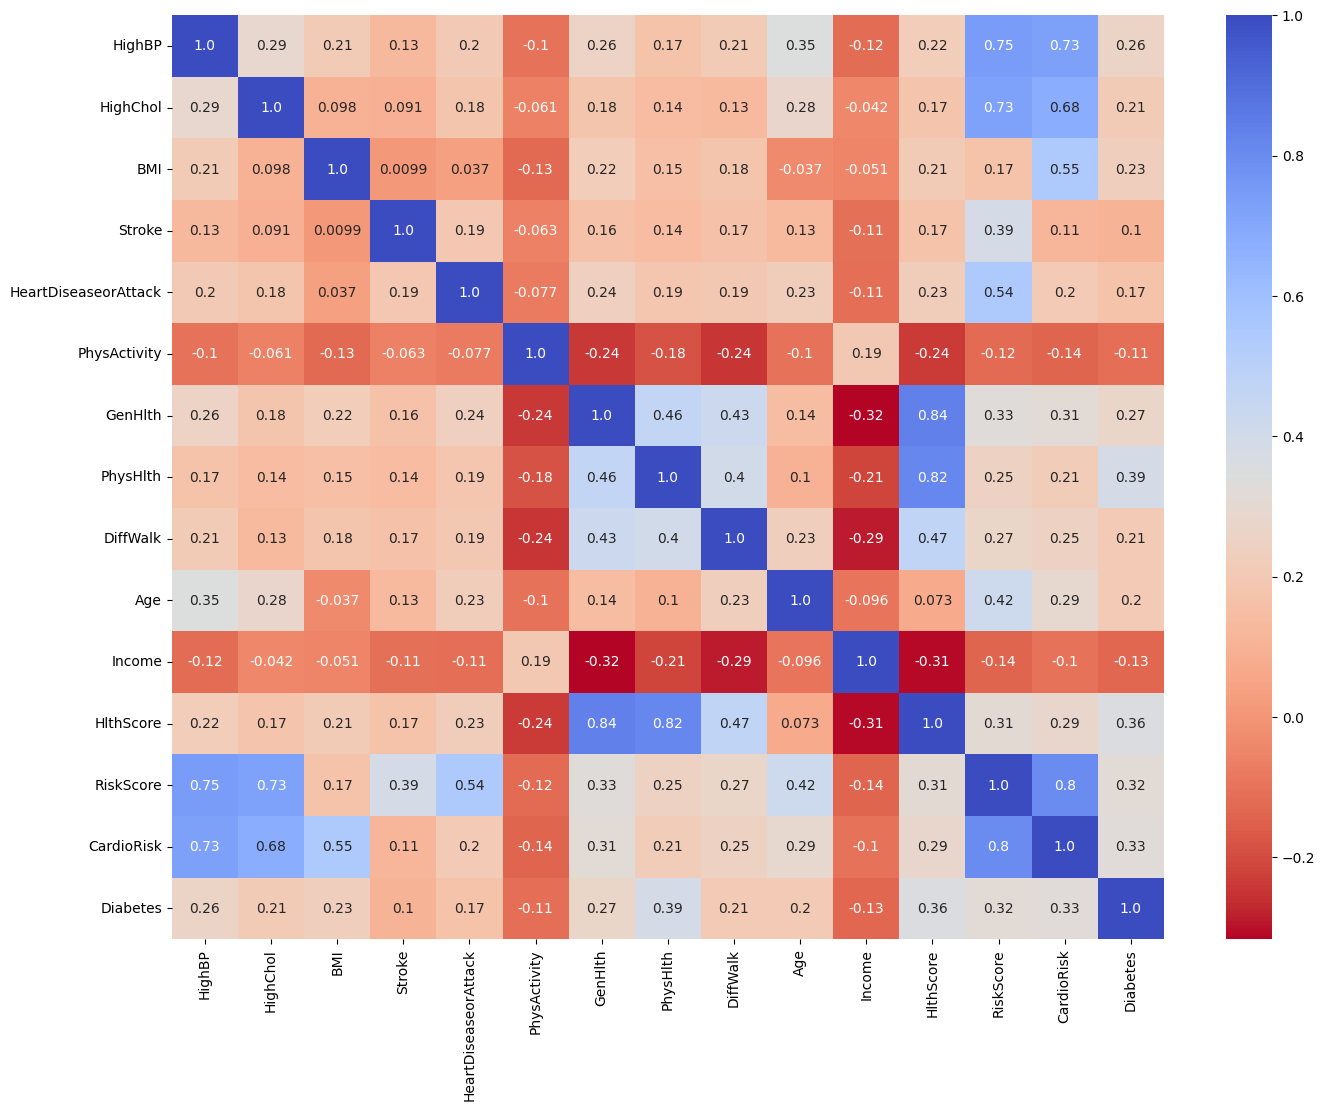

In [34]:
# Visualize feature correlations to identify potential multicollinearity
# Red indicates positive correlation, blue indicates negative correlation
plt.figure(figsize=(16, 12))
ax = sns.heatmap(final_df.corr(), cmap='coolwarm_r', fmt='.2', annot=True)
plt.show()

## **3. Conclusion**

The final result is a clean, compact dataset with features that have high correlation with the target and also includes engineered features that bring domain knowledge about diabetes risk factors. The final correlation heatmap shows the relationships between selected features and can help identify potential multicollinearity issues.

This feature engineering process was successful in:

1. Cleaning the data (removing duplicates, outliers)
2. Creating meaningful features from domain knowledge
3. Reducing dimensionality while keeping informative features
4. Preparing a high-quality dataset for the modeling phase